In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ndomalau/personal-protective-equipment-ppe-dataset")

print("Path to dataset files:", path)

100%|██████████| 238M/238M [00:02<00:00, 86.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1


## Discover dataset layout


In [3]:
import os
import glob
import yaml

DATASET_PATH = path

def find_data_yaml(root):
    """Look for a YOLO data.yaml/data.yml anywhere in the downloaded dataset."""
    candidates = glob.glob(os.path.join(root, "**", "*.yaml"), recursive=True)
    candidates += glob.glob(os.path.join(root, "**", "*.yml"), recursive=True)
    # Prefer files literally named data.yaml / data.yml
    preferred = [c for c in candidates if os.path.basename(c).lower() in ("data.yaml", "data.yml")]
    return (preferred or candidates or [None])[0]

def find_split_dirs(root):
    """Find split folders that contain an images/ subfolder (train/val/valid/test, case-insensitive)."""
    known_splits = ["train", "val", "valid", "validation", "test"]
    found = {}
    for dirpath, dirnames, _ in os.walk(root):
        base = os.path.basename(dirpath).lower()
        if base in known_splits and "images" in [d.lower() for d in dirnames]:
            # normalize the actual images/labels dir names
            actual = {d.lower(): d for d in dirnames}
            img_dir = os.path.join(dirpath, actual["images"])
            lbl_dir = os.path.join(dirpath, actual["labels"]) if "labels" in actual else None
            found[base] = {"images": img_dir, "labels": lbl_dir}
    return found

YAML_PATH = find_data_yaml(DATASET_PATH)
CLASS_NAMES = None
if YAML_PATH:
    with open(YAML_PATH) as f:
        data_cfg = yaml.safe_load(f)
    names = data_cfg.get("names")
    if isinstance(names, dict):
        CLASS_NAMES = [names[i] for i in sorted(names, key=lambda x: int(x))]
    elif isinstance(names, list):
        CLASS_NAMES = names
    print(f"Found data.yaml at: {YAML_PATH}")
    print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
else:
    print("No data.yaml found — class names must be set manually below.")

SPLIT_DIRS = find_split_dirs(DATASET_PATH)
print("\nDetected splits:")
for split, dirs in SPLIT_DIRS.items():
    n_img = len(os.listdir(dirs["images"])) if dirs["images"] and os.path.isdir(dirs["images"]) else 0
    n_lbl = len(os.listdir(dirs["labels"])) if dirs["labels"] and os.path.isdir(dirs["labels"]) else 0
    print(f"  {split}: {n_img} images, {n_lbl} labels  (images: {dirs['images']})")

SPLITS = list(SPLIT_DIRS.keys())


if CLASS_NAMES is None:
    CLASS_NAMES = ["helmet", "vest", "person"]
    print("\n⚠️ Using fallback CLASS_NAMES — please verify these against the dataset's actual class list:", CLASS_NAMES)

NUM_CLASSES = len(CLASS_NAMES)


Found data.yaml at: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1/Personal-Protective-Equipment (PPE) Dataset/data.yaml
Classes (5): ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']

Detected splits:
  train: 3248 images, 3248 labels  (images: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1/Personal-Protective-Equipment (PPE) Dataset/train/images)
  valid: 406 images, 406 labels  (images: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1/Personal-Protective-Equipment (PPE) Dataset/valid/images)
  test: 406 images, 406 labels  (images: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1/Personal-Protective-Equipment (PPE) Dataset/test/images)


In [4]:
# Show contents of image and label directories for every detected split
for split, dirs in SPLIT_DIRS.items():
    n_img = len(os.listdir(dirs["images"])) if dirs["images"] else 0
    print(f"{split.capitalize()} images:", n_img)


Train images: 3248
Valid images: 406
Test images: 406


In [5]:
# Write out the YAML config file for YOLO training, based on what was actually detected
yaml_content_lines = [f"path: {DATASET_PATH}"]
for split in SPLITS:
    rel = os.path.relpath(SPLIT_DIRS[split]["images"], DATASET_PATH)
    yaml_content_lines.append(f"{split}: {rel}")
yaml_content_lines.append(f"nc: {NUM_CLASSES}")
yaml_content_lines.append(f"names: {CLASS_NAMES}")
yaml_content = "\n".join(yaml_content_lines) + "\n"

with open('ppe.yaml', 'w') as f:
    f.write(yaml_content)

print(yaml_content)
print("✅ YAML for the PPE dataset created!")


path: /root/.cache/kagglehub/datasets/ndomalau/personal-protective-equipment-ppe-dataset/versions/1
train: Personal-Protective-Equipment (PPE) Dataset/train/images
valid: Personal-Protective-Equipment (PPE) Dataset/valid/images
test: Personal-Protective-Equipment (PPE) Dataset/test/images
nc: 5
names: ['helmet', 'no_helmet', 'no_vest', 'person', 'vest']

✅ YAML for the PPE dataset created!


## Dataset validation
Checks image/label pairing, malformed annotation lines, corrupt images, and class balance across splits.

In [6]:
def check_image_label_pairing(split_dirs, split):
    img_dir = split_dirs[split]["images"]
    lbl_dir = split_dirs[split]["labels"]

    img_stems = {os.path.splitext(f)[0] for f in os.listdir(img_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
    lbl_stems = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)
                 if f.lower().endswith('.txt')} if lbl_dir else set()

    images_without_labels = img_stems - lbl_stems
    labels_without_images = lbl_stems - img_stems

    print(f"--- {split} ---")
    print(f"  images: {len(img_stems)}  labels: {len(lbl_stems)}")
    print(f"  images without a label file: {len(images_without_labels)}")
    print(f"  label files without an image: {len(labels_without_images)}")
    if images_without_labels:
        print("  e.g.", list(images_without_labels)[:5])
    if labels_without_images:
        print("  e.g.", list(labels_without_images)[:5])
    return images_without_labels, labels_without_images

for split in SPLITS:
    check_image_label_pairing(SPLIT_DIRS, split)


--- train ---
  images: 3248  labels: 3248
  images without a label file: 0
  label files without an image: 0
--- valid ---
  images: 406  labels: 406
  images without a label file: 0
  label files without an image: 0
--- test ---
  images: 406  labels: 406
  images without a label file: 0
  label files without an image: 0


In [7]:
def validate_label_files(split_dirs, split, num_classes=NUM_CLASSES):

    lbl_dir = split_dirs[split]["labels"]
    bad_files = []
    if not lbl_dir:
        print(f"--- {split}: no labels directory found, skipping ---")
        return bad_files

    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        fpath = os.path.join(lbl_dir, fname)
        with open(fpath) as f:
            for line_num, line in enumerate(f, 1):
                parts = line.strip().split()
                if not parts:
                    continue
                if len(parts) != 5:
                    bad_files.append((fname, line_num, "wrong number of fields"))
                    continue
                try:
                    class_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                except ValueError:
                    bad_files.append((fname, line_num, "non-numeric value"))
                    continue
                if not (0 <= class_id < num_classes):
                    bad_files.append((fname, line_num, f"class_id {class_id} out of range"))
                if not all(0.0 <= c <= 1.0 for c in coords):
                    bad_files.append((fname, line_num, "coordinate out of [0,1]"))

    print(f"--- {split}: {len(bad_files)} problem line(s) ---")
    for fname, line_num, reason in bad_files[:10]:
        print(f"  {fname} (line {line_num}): {reason}")
    return bad_files

for split in SPLITS:
    validate_label_files(SPLIT_DIRS, split, num_classes=NUM_CLASSES)


--- train: 0 problem line(s) ---
--- valid: 0 problem line(s) ---
--- test: 0 problem line(s) ---


### Class Distribution

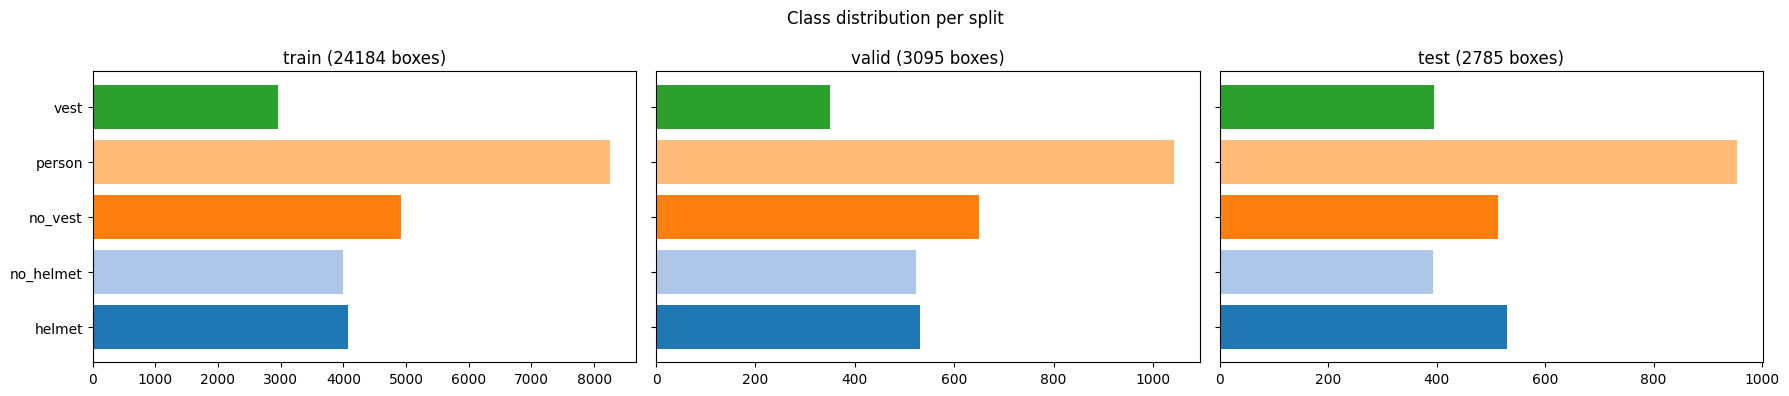

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

def class_distribution(split_dirs, split):
    lbl_dir = split_dirs[split]["labels"]
    counts = Counter()
    if not lbl_dir:
        return counts
    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

fig, axes = plt.subplots(1, len(SPLITS), figsize=(6 * len(SPLITS), max(4, NUM_CLASSES * 0.3)), sharey=True)
if len(SPLITS) == 1:
    axes = [axes]
for ax, split in zip(axes, SPLITS):
    counts = class_distribution(SPLIT_DIRS, split)
    values = [counts.get(i, 0) for i in range(NUM_CLASSES)]
    ax.barh(CLASS_NAMES, values, color=plt.cm.tab20.colors[:NUM_CLASSES])
    ax.set_title(f"{split} ({sum(values)} boxes)")

plt.suptitle("Class distribution per split")
plt.tight_layout()
plt.show()


## Visualize Random Samples

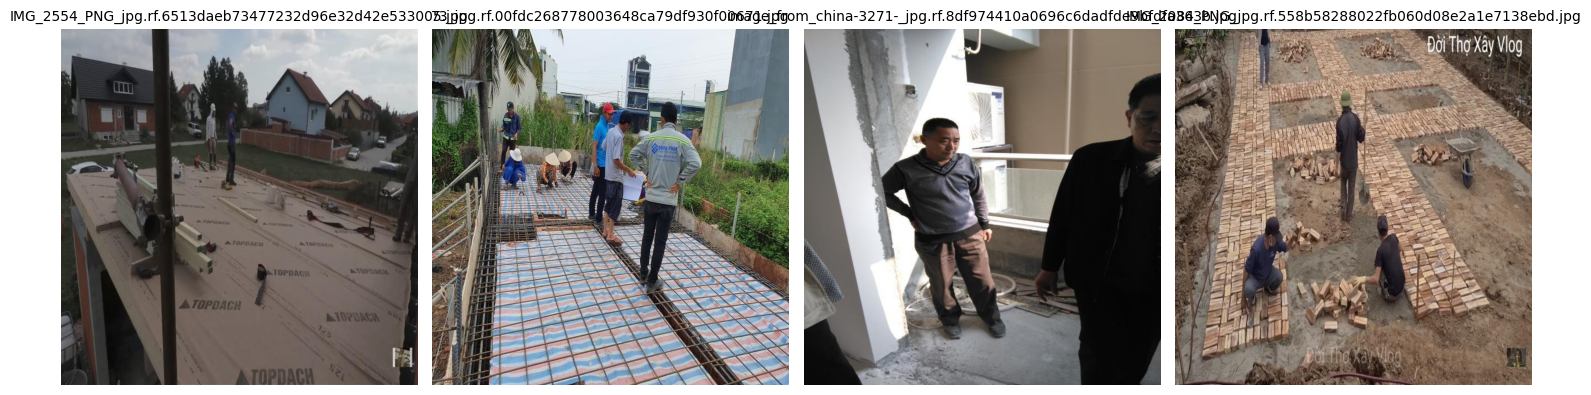

In [11]:
import random
import cv2

def visualize_raw_training_images(image_dir, num_images=4):

    # Get all image filenames in the training directory
    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)]

    if not all_images:
        print(f"No images found in {image_dir}")
        return

    # Pick a random sample of images
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Set up a grid to display them
    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 5))
    if len(selected_images) == 1:
        axes = [axes]  # Handle case for a single image

    for ax, img_name in zip(axes, selected_images):
        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            # Convert BGR to RGB for correct colors in Matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(img_name, fontsize=10)
        else:
            ax.set_title(f"Failed to load: {img_name}", fontsize=10)

        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- Run the function ---
TRAIN_SPLIT = "train" if "train" in SPLIT_DIRS else SPLITS[0]
TRAIN_IMAGE_DIR = SPLIT_DIRS[TRAIN_SPLIT]["images"]
visualize_raw_training_images(TRAIN_IMAGE_DIR, num_images=4)


### Visual Bounding Box Verification

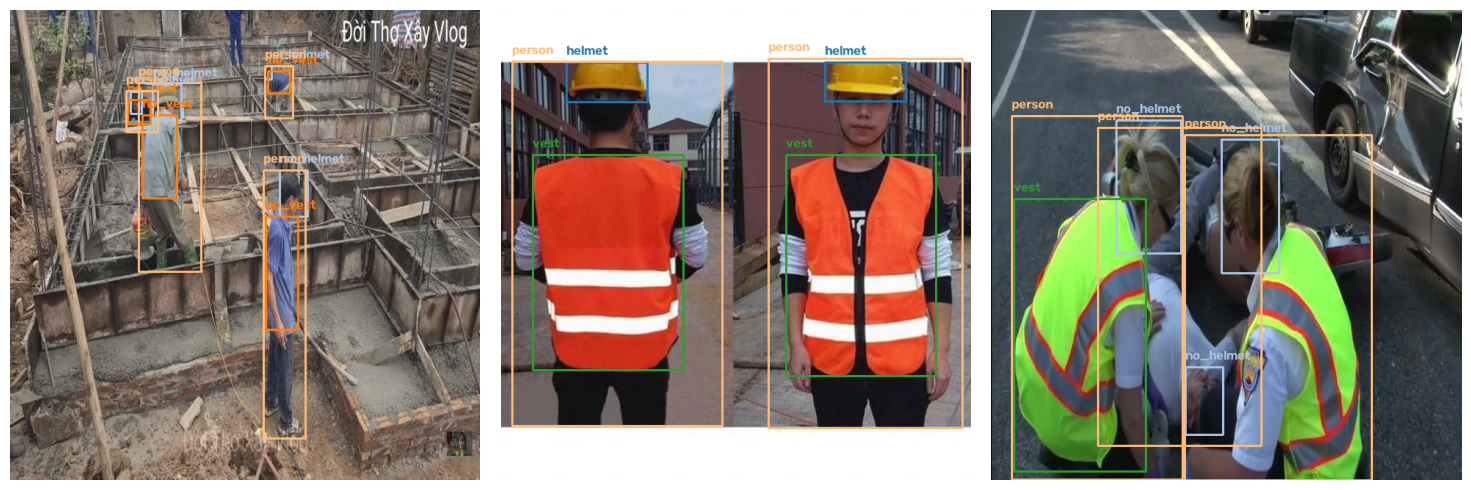

In [28]:
from PIL import Image

def visualize_random_samples(split_dirs, split, num_samples=3):
    img_dir = split_dirs[split]["images"]
    lbl_dir = split_dirs[split]["labels"]

    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_imgs = random.sample(images, min(num_samples, len(images)))

    palette = plt.cm.tab20.colors

    plt.figure(figsize=(15, 5))
    for idx, img_name in enumerate(sample_imgs):
        img_path = os.path.join(img_dir, img_name)
        stem = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, f"{stem}.txt") if lbl_dir else None

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Read labels
        if lbl_path and os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        x_center, y_center, box_w, box_h = map(float, parts[1:])

                        # Convert YOLO normalized coords to pixel coords
                        xmin = int((x_center - box_w / 2) * w)
                        ymin = int((y_center - box_h / 2) * h)
                        xmax = int((x_center + box_w / 2) * w)
                        ymax = int((y_center + box_h / 2) * h)

                        # Draw box
                        color = tuple(int(c * 255) for c in palette[cls_id % len(palette)])
                        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
                        label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                        cv2.putText(img, label, (xmin, max(ymin - 10, 10)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        plt.subplot(1, num_samples, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.tight_layout()
    plt.show()

visualize_random_samples(SPLIT_DIRS, TRAIN_SPLIT, num_samples=3)


### Degenerate Bounding Box Check
Sometimes annotation tools export boxes with width or height equal to 0.0, which can cause division-by-zero errors or NaN losses during training.

In [16]:
def check_degenerate_boxes(split_dirs, split):
    lbl_dir = split_dirs[split]["labels"]
    degenerate_count = 0
    if not lbl_dir:
        print(f"--- {split}: no labels directory found, skipping ---")
        return

    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, _, _, w, h = map(float, parts)
                    if w == 0.0 or h == 0.0:
                        degenerate_count += 1

    print(f"--- {split}: {degenerate_count} degenerate box(es) found (w or h == 0) ---")

for split in SPLITS:
    check_degenerate_boxes(SPLIT_DIRS, split)


--- train: 0 degenerate box(es) found (w or h == 0) ---
--- valid: 0 degenerate box(es) found (w or h == 0) ---
--- test: 0 degenerate box(es) found (w or h == 0) ---


### Check Safety for Helmet & Vest

In [33]:

NEGATIVE_MARKERS = ["no_", "no-", "without", "missing", "not_"]

def _is_negative(lname):
    return any(marker in lname for marker in NEGATIVE_MARKERS)

def _find_class_index(keywords, negative=False):
    for i, name in enumerate(CLASS_NAMES):
        lname = name.lower().replace(" ", "_")
        if any(k in lname for k in keywords) and _is_negative(lname) == negative:
            return i
    return None

HELMET_CLASS_ID = _find_class_index(["helmet", "hardhat", "hard_hat"])
VEST_CLASS_ID = _find_class_index(["vest"])
NO_HELMET_CLASS_ID = _find_class_index(["helmet", "hardhat", "hard_hat"], negative=True)
NO_VEST_CLASS_ID = _find_class_index(["vest"], negative=True)

print("Helmet class:", CLASS_NAMES[HELMET_CLASS_ID] if HELMET_CLASS_ID is not None else "not found")
print("No-helmet class:", CLASS_NAMES[NO_HELMET_CLASS_ID] if NO_HELMET_CLASS_ID is not None else "not found")
print("Vest class:", CLASS_NAMES[VEST_CLASS_ID] if VEST_CLASS_ID is not None else "not found")
print("No-vest class:", CLASS_NAMES[NO_VEST_CLASS_ID] if NO_VEST_CLASS_ID is not None else "not found")

def check_safety_compliance(detected_classes):
    has_helmet = HELMET_CLASS_ID is not None and HELMET_CLASS_ID in detected_classes
    has_vest = VEST_CLASS_ID is not None and VEST_CLASS_ID in detected_classes

    if has_helmet and has_vest:
        return "Wearing both (Helmet & Vest)", (0, 255, 0)      # green
    elif has_helmet and not has_vest:
        return "Wearing Helmet only (No Vest)", (0, 165, 255)   # orange
    elif not has_helmet and has_vest:
        return "Wearing Vest only (No Helmet)", (0, 165, 255)   # orange
    else:
        return "Wearing neither", (0, 0, 255)


Helmet class: helmet
No-helmet class: no_helmet
Vest class: vest
No-vest class: no_vest


In [34]:
import cv2
import matplotlib.pyplot as plt

def visualize_yolo_with_compliance(image_path, label_path, class_names):

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image from: {image_path}")
        return

    h, w, _ = img.shape
    detected_classes = []
    palette = plt.cm.tab20.colors

    # Read label file if it exists
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue

            class_id = int(parts[0])
            detected_classes.append(class_id)

            x_center, y_center, box_width, box_height = map(float, parts[1:])

            # Convert YOLO normalized coordinates to pixel coordinates
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            color = tuple(int(c * 255) for c in palette[class_id % len(palette)])
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            label_text = class_names[class_id] if class_id < len(class_names) else str(class_id)
            cv2.putText(img, label_text, (x1, max(y1 - 10, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    else:
        print(f"Label file not found: {label_path}")

    # Evaluate compliance based on all objects found in the frame
    status_text, status_color = check_safety_compliance(detected_classes)

    # Overlay compliance status banner at the top of the image
    cv2.putText(img, f"Status: {status_text}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, status_color, 3, cv2.LINE_AA)

    # Convert BGR to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 9))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("YOLO Safety Compliance Visualization", fontsize=14)
    plt.show()


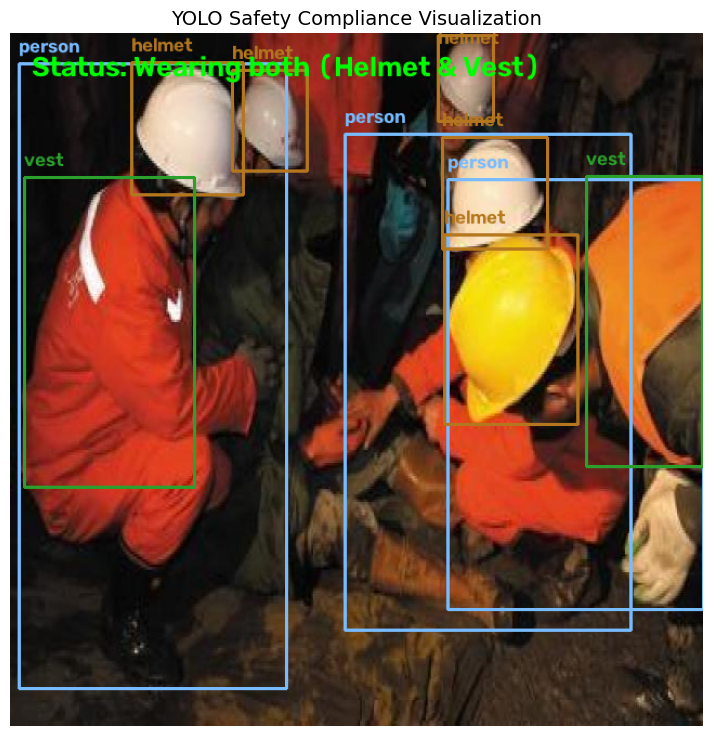

In [36]:
# --- Example Usage 1 ---
sample_img_dir = SPLIT_DIRS[TRAIN_SPLIT]["images"]
sample_lbl_dir = SPLIT_DIRS[TRAIN_SPLIT]["labels"]
sample_images = [f for f in os.listdir(sample_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

img_name = random.choice(sample_images)
stem = os.path.splitext(img_name)[0]
img_file = os.path.join(sample_img_dir, img_name)
lbl_file = os.path.join(sample_lbl_dir, f"{stem}.txt") if sample_lbl_dir else ""
visualize_yolo_with_compliance(img_file, lbl_file, CLASS_NAMES)
